# Zadanie 3: Eksploracyjna analiza danych (EDA) i detekcja outlierów
## Analiza rynku mieszkań w Warszawie

In [1]:
# Import pakietów
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

# Ustawienie ładniejszego stylu wykresów
sns.set_theme(style="whitegrid")

## Część 1 — Wstępna eksploracja (2 pkt)
Wczytujemy dane i na szybko sprawdzamy ich rozmiar, braki oraz podstawowe statystyki, żeby wyłapać pierwsze anomalie.

In [2]:
# Wczytanie pliku
df = pd.read_csv("mieszkania_warszawa.csv")

# Wstępna ocena zbioru
print("Kształt zbioru (shape):", df.shape)
print("\n--- INFORMACJE O TYPACH DANYCH (info) ---")
df.info()

print("\n--- STATYSTYKI OPISOWE (describe) ---")
display(df.describe())

print("\n--- LICZBA BRAKUJĄCYCH WARTOŚCI (isnull().sum()) ---")
print(df.isnull().sum())

Kształt zbioru (shape): (2000, 10)

--- INFORMACJE O TYPACH DANYCH (info) ---
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_oferty                2000 non-null   int64  
 1   dzielnica                2000 non-null   str    
 2   metraz_m2                2000 non-null   float64
 3   liczba_pokoi             2000 non-null   int64  
 4   pietro                   2000 non-null   int64  
 5   rok_budowy               2000 non-null   int64  
 6   ma_balkon                2000 non-null   bool   
 7   ma_miejsce_parkingowe    2000 non-null   bool   
 8   odleglosc_od_centrum_km  2000 non-null   float64
 9   cena_pln                 2000 non-null   float64
dtypes: bool(2), float64(3), int64(4), str(1)
memory usage: 129.0 KB

--- STATYSTYKI OPISOWE (describe) ---


,id_oferty,metraz_m2,liczba_pokoi,pietro,rok_budowy,odleglosc_od_centrum_km,cena_pln
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,11000.500000,56.965758,3.085500,5.415500,1993.889500,6.222265,8.809612e+05
std,577.494589,30.787760,1.264907,3.501998,21.076632,3.909166,7.499763e+05
min,10001.000000,18.000000,1.000000,0.000000,1800.000000,0.500000,6.177632e+04
25%,10500.750000,40.800000,2.000000,2.000000,1979.000000,3.350000,5.685120e+05
50%,11000.500000,55.350000,3.000000,5.000000,1997.000000,5.550000,8.095755e+05
75%,11500.250000,69.900000,4.000000,8.000000,2011.000000,8.322500,1.070190e+06
max,12000.000000,585.187341,6.000000,11.000000,2050.000000,25.000000,2.292390e+07



--- LICZBA BRAKUJĄCYCH WARTOŚCI (isnull().sum()) ---
id_oferty                  0
dzielnica                  0
metraz_m2                  0
liczba_pokoi               0
pietro                     0
rok_budowy                 0
ma_balkon                  0
ma_miejsce_parkingowe      0
odleglosc_od_centrum_km    0
cena_pln                   0
dtype: int64


### Co widać na pierwszy rzut oka?
W danych od razu rzuca się w oczy kilka dziwnych rzeczy:
1. **Dziwny metraż:** Maksymalna wartość to aż **585.2 m²** – przy średniej ~57 m² brzmi to jak gruby błąd lub skrajny przypadek.
2. **Rozstrzał cen:** Najtańsze mieszkanie kosztuje **61 776 PLN** (za tanio na Warszawę), a najdroższe prawie **23 miliony PLN**! To sugeruje błędy w danych lub jakieś nietypowe apartamenty.
3. **Rok budowy:** Pojawiają się nierealne daty typu 1800 albo 2050 rok.
4. **Braki danych:** Dobra wiadomość jest taka, że nie mamy żadnych braków (pustych komórek) w tabeli.

## Część 2 — Statystyki opisowe (3 pkt)
Liczymy podstawowe miary statystyczne: średnią, medianę, kwartyle, a także skośność i kurtozę dla najważniejszych kolumn.

In [3]:
# 1. Statystyki dla cena_pln
cena_mean = df["cena_pln"].mean()
cena_median = df["cena_pln"].median()
cena_std = df["cena_pln"].std()
cena_skew = df["cena_pln"].skew()
cena_kurt = df["cena_pln"].kurt()

print("--- Statystyki opisowe dla 'cena_pln' ---")
print(f"Średnia:                 {cena_mean:.2f} PLN")
print(f"Mediana:                 {cena_median:.2f} PLN")
print(f"Odchylenie standardowe:  {cena_std:.2f} PLN")
print(f"Skośność (skewness):     {cena_skew:.2f}")
print(f"Kurtoza (kurtosis):      {cena_kurt:.2f}")

# 2. Kwartyle i IQR dla metraz_m2
metraz_q1 = df["metraz_m2"].quantile(0.25)
metraz_q3 = df["metraz_m2"].quantile(0.75)
metraz_iqr = metraz_q3 - metraz_q1

print("\n--- Statystyki opisowe dla 'metraz_m2' ---")
print(f"Q1 (25 percentyl):       {metraz_q1:.2f} m²")
print(f"Q3 (75 percentyl):       {metraz_q3:.2f} m²")
print(f"IQR (rozstęp ćwiartkowy): {metraz_iqr:.2f} m²")

# 3. Liczba unikalnych dzielnic i ofert na każdą dzielnicę
print(f"\nLiczba unikalnych dzielnic: {df['dzielnica'].nunique()}")
print("\nLiczba ofert na dzielnicę (value_counts):")
print(df["dzielnica"].value_counts())

--- Statystyki opisowe dla 'cena_pln' ---
Średnia:                 880961.21 PLN
Mediana:                 809575.50 PLN
Odchylenie standardowe:  749976.28 PLN
Skośność (skewness):     15.86
Kurtoza (kurtosis):      404.22

--- Statystyki opisowe dla 'metraz_m2' ---
Q1 (25 percentyl):       40.80 m²
Q3 (75 percentyl):       69.90 m²
IQR (rozstęp ćwiartkowy): 29.10 m²

Liczba unikalnych dzielnic: 11

Liczba ofert na dzielnicę (value_counts):
dzielnica
Mokotów           210
Targówek          189
Ursynów           189
Śródmieście       189
Ochota            188
Wola              178
Białołęka         177
Bemowo            176
Bielany           174
Praga-Południe    166
Wilanów           164
Name: count, dtype: int64


### Skośność i kurtoza ceny — co to oznacza?
- **Skośność (15.86):** Rozkład ma bardzo silną skośność prawostronną (długi prawy ogon). Większość mieszkań kosztuje w okolicach mediany (~810 tys. PLN), ale kilka kosmicznie drogich ofert (nawet 22.9 mln PLN) mocno ciągnie średnią w górę (do ponad 880 tys. PLN).
- **Kurtoza (404.22):** Bardzo wysoka wartość oznacza rozkład leptokurtyczny (smukły z grubymi ogonami). Mamy bardzo wyraźny pik wokół typowych cen oraz sporo skrajnych obserwacji leżących daleko poza normą.

## Część 3 — Analiza pojedynczych zmiennych (3 pkt)
Rysujemy wykresy (histogramy, KDE, boxploty i wykresy częstości), żeby lepiej przyjrzeć się rozkładom poszczególnych kolumn.

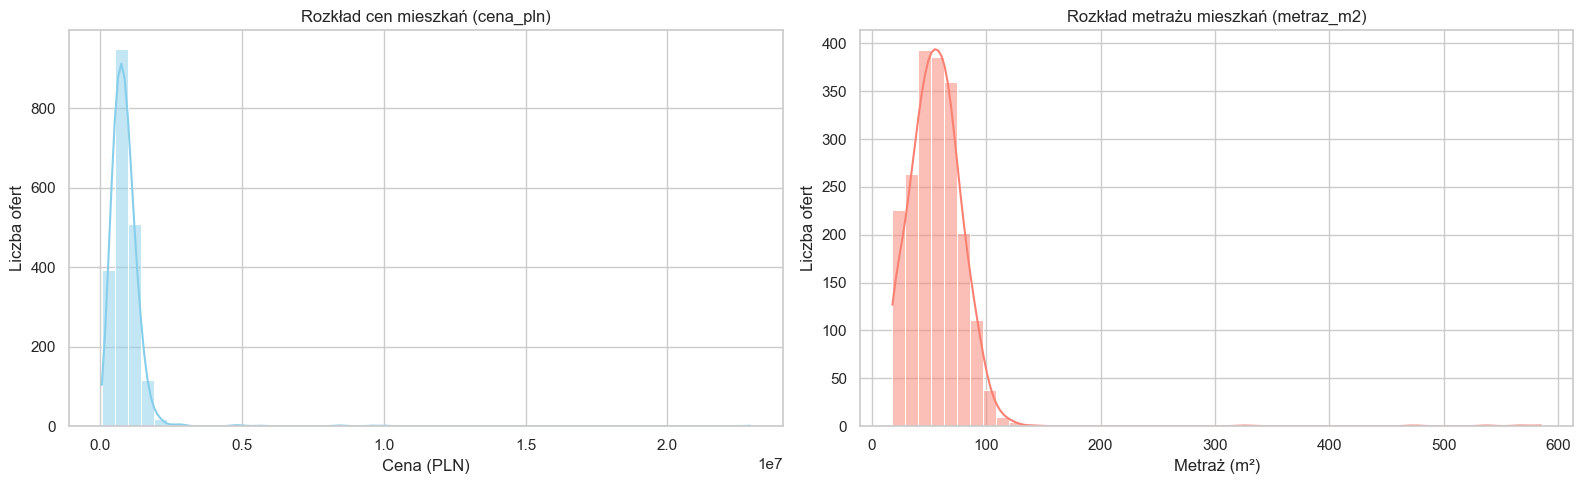

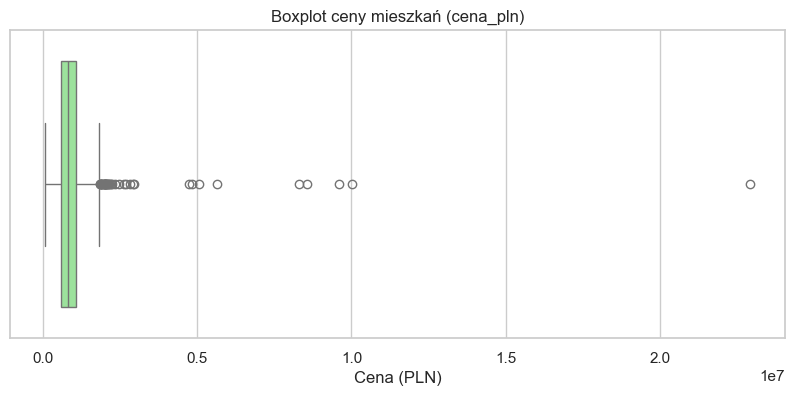

C:\Users\Damian\AppData\Local\Temp\ipykernel_19336\746198026.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="dzielnica", order=order_dzielnice, palette="viridis")


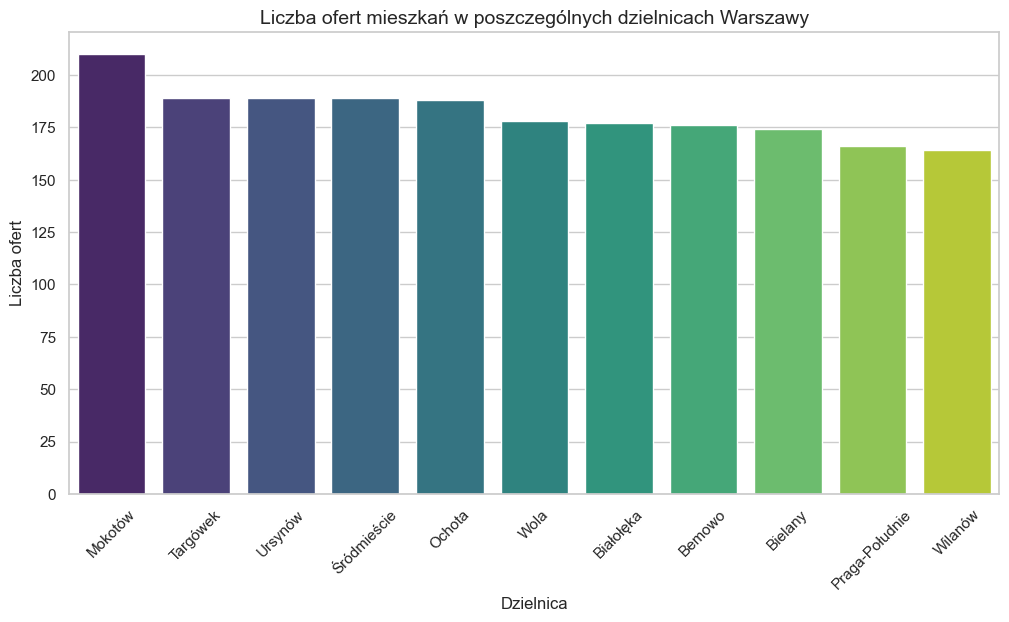

In [4]:
# 1. Histogram + KDE dla cena_pln i metraz_m2
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram ceny
sns.histplot(df["cena_pln"], bins=50, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Rozkład cen mieszkań (cena_pln)", fontsize=12)
axes[0].set_xlabel("Cena (PLN)")
axes[0].set_ylabel("Liczba ofert")

# Histogram metrażu
sns.histplot(df["metraz_m2"], bins=50, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Rozkład metrażu mieszkań (metraz_m2)", fontsize=12)
axes[1].set_xlabel("Metraż (m²)")
axes[1].set_ylabel("Liczba ofert")

plt.tight_layout()
plt.show()

# 2. Boxplot dla cena_pln
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["cena_pln"], color="lightgreen")
plt.title("Boxplot ceny mieszkań (cena_pln)", fontsize=12)
plt.xlabel("Cena (PLN)")
plt.show()

# 3. Countplot pokazujący liczność ofert w każdej dzielnicy (posortowany malejąco)
plt.figure(figsize=(12, 6))
order_dzielnice = df["dzielnica"].value_counts().index
sns.countplot(data=df, x="dzielnica", order=order_dzielnice, palette="viridis")
plt.title("Liczba ofert mieszkań w poszczególnych dzielnicach Warszawy", fontsize=14)
plt.xlabel("Dzielnica", fontsize=12)
plt.ylabel("Liczba ofert", fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Wnioski z wykresów:
1. **Histogramy i KDE:** Rozkład ceny jest skrajnie przesunięty w lewo z gigantycznym ogonem po prawej. Z metrażem jest podobnie: większość mieszkań mieści się w standardowych 40-80 m², ale mamy pojedyncze ogromne lokale powyżej 300 m².
2. **Boxplot ceny:** Wykres pudełkowy jest mocno spłaszczony z prawej strony przez chmurę punktów odstających (outlierów), co potwierdza asymetrię i obecność nietypowych ofert.
3. **Liczba ofert per dzielnica:** Rozkład jest całkiem równy. Najwięcej ofert ma Mokotów (210), a najmniej Wilanów (164). Każda dzielnica jest dobrze reprezentowana.

## Część 4 — Analiza zależności (3 pkt)
Sprawdzamy, jak zmienne wpływają na siebie nawzajem – badamy korelacje, ceny za metr w dzielnicach i zależność ceny od metrażu.

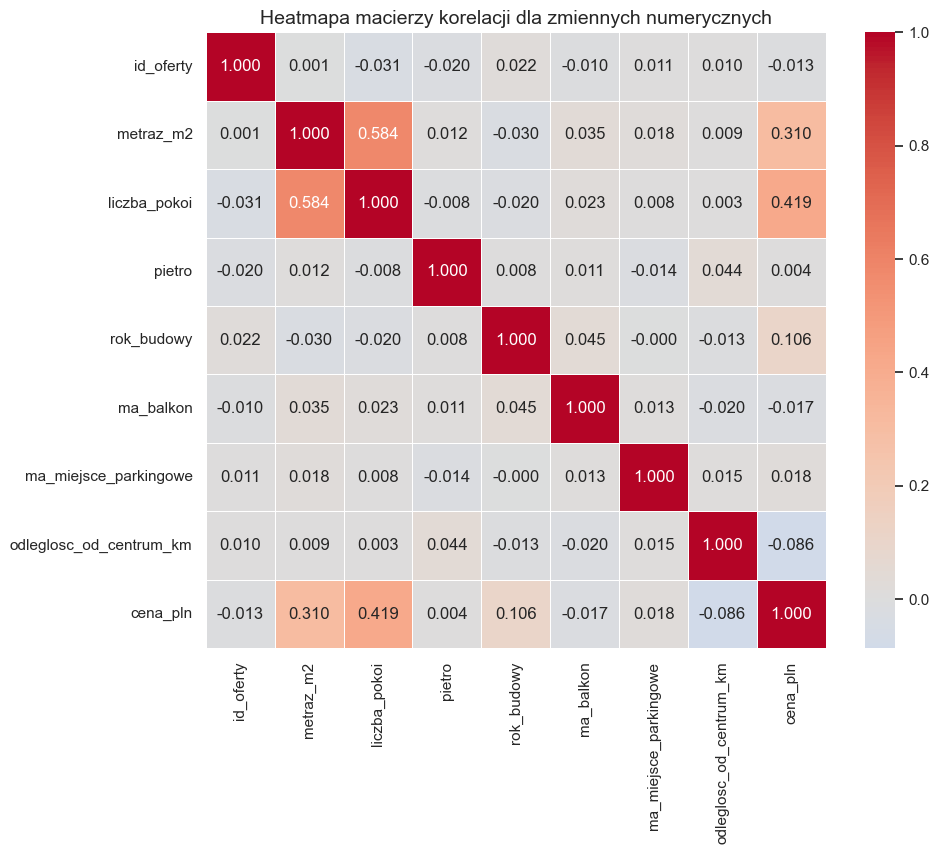

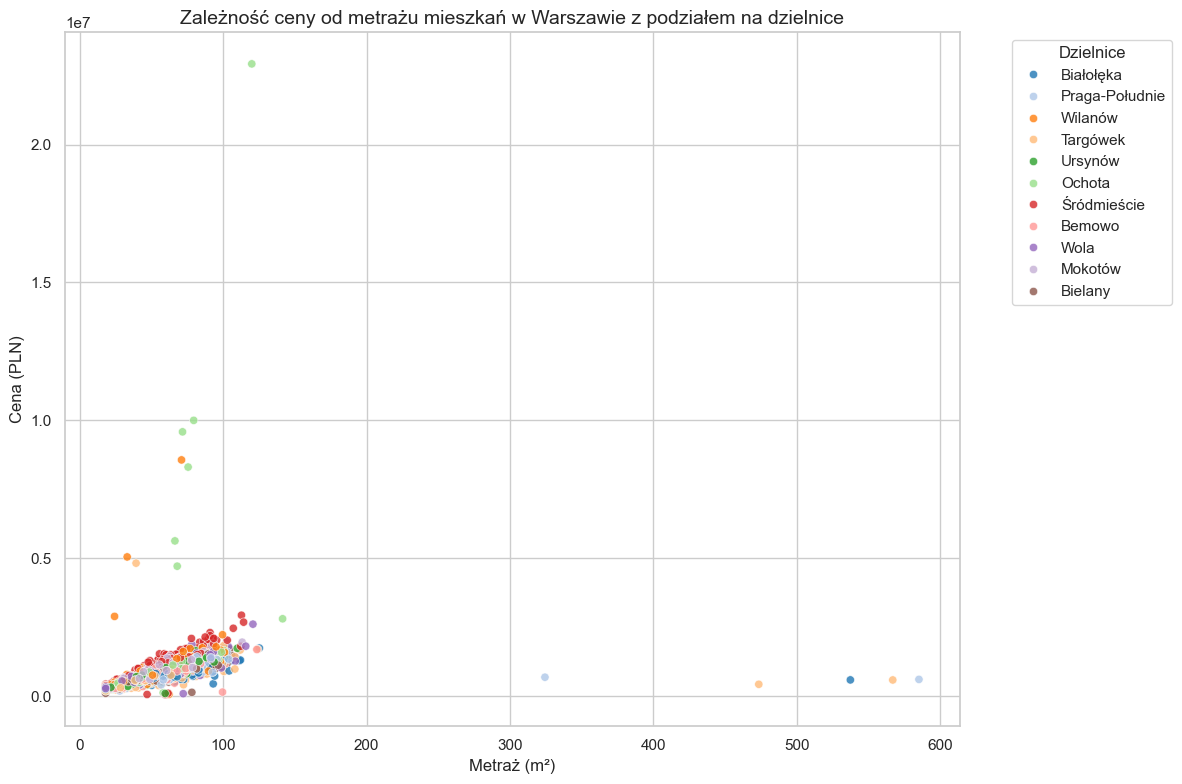

C:\Users\Damian\AppData\Local\Temp\ipykernel_19336\4241324927.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="dzielnica", y="cena_pln_per_m2", order=order_cena_m2, palette="Set3")


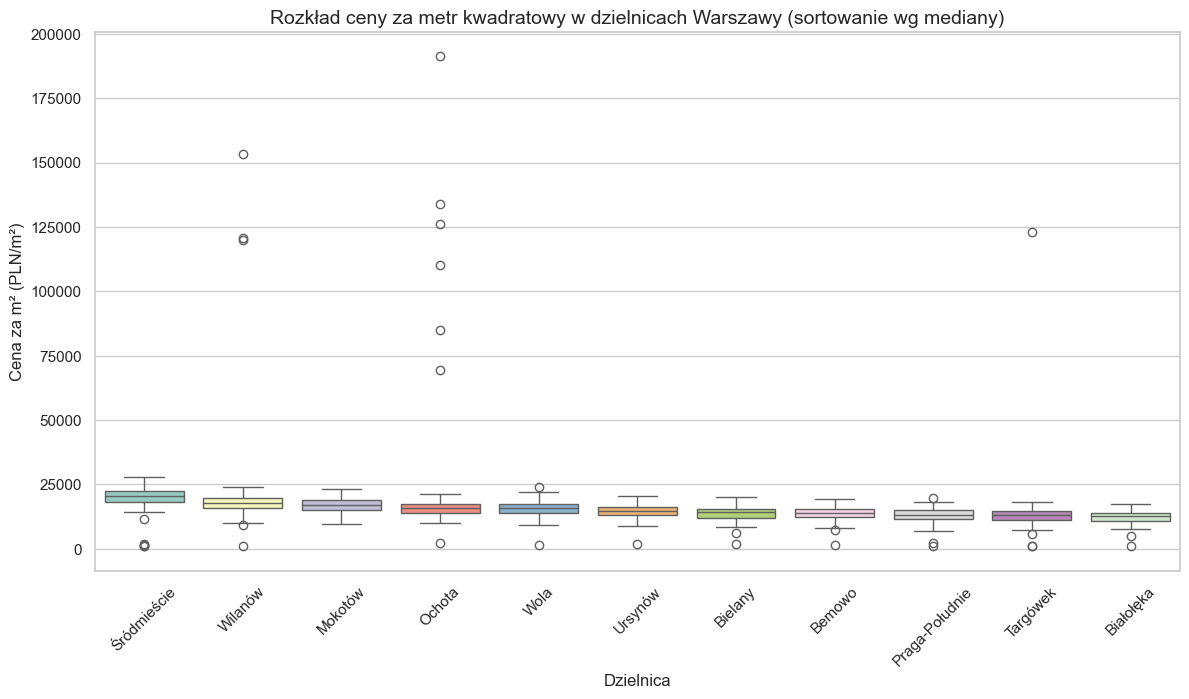

In [5]:
# 1. Heatmapa macierzy korelacji dla zmiennych numerycznych
df_corr = df.copy()
df_corr["ma_balkon"] = df_corr["ma_balkon"].astype(int)
df_corr["ma_miejsce_parkingowe"] = df_corr["ma_miejsce_parkingowe"].astype(int)
corr_matrix = df_corr.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".3f", linewidths=0.5)
plt.title("Heatmapa macierzy korelacji dla zmiennych numerycznych", fontsize=14)
plt.show()

# 2. Scatter plot metraz_m2 vs cena_pln z podziałem na dzielnice
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x="metraz_m2", y="cena_pln", hue="dzielnica", palette="tab20", alpha=0.8)
plt.title("Zależność ceny od metrażu mieszkań w Warszawie z podziałem na dzielnice", fontsize=14)
plt.xlabel("Metraż (m²)", fontsize=12)
plt.ylabel("Cena (PLN)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Dzielnice")
plt.tight_layout()
plt.show()

# 3. Boxplot ceny za m² (cena_pln / metraz_m2) w podziale na dzielnice
df["cena_pln_per_m2"] = df["cena_pln"] / df["metraz_m2"]

# Ustalenie kolejności według mediany ceny za m2 malejąco
order_cena_m2 = df.groupby("dzielnica")["cena_pln_per_m2"].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x="dzielnica", y="cena_pln_per_m2", order=order_cena_m2, palette="Set3")
plt.title("Rozkład ceny za metr kwadratowy w dzielnicach Warszawy (sortowanie wg mediany)", fontsize=14)
plt.xlabel("Dzielnica", fontsize=12)
plt.ylabel("Cena za m² (PLN/m²)", fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Jak zmienne wpływają na cenę?
1. **Co ma największy wpływ?** Najmocniej z ceną koreluje liczba pokoi (**0.42**) oraz metraż (**0.31**). Zależność od odległości od centrum jest słaba i ujemna (**-0.09**), co oznacza, że im dalej od centrum, tym bywa ciut taniej.
2. **Wykres rozrzutu (Scatter plot):** Dla standardowych mieszkań (20-100 m²) cena rośnie liniowo wraz z metrażem. Widać jednak spore anomalie: bardzo małe mieszkania z kosmicznymi cenami i na odwrót.
3. **Gdzie najdrożej, a gdzie najtaniej?** Zgodnie z przewidywaniami najdroższe za metr jest **Śródmieście** (mediana **~20.4k PLN/m²**), a za nim Wilanów i Mokotów. Najtaniej kupimy na **Białołęce** (mediana **~12.6k PLN/m²**).

## Część 5 — Detekcja outlierów (4 pkt)
Wyszukujemy wartości odstające (outliery) w cenach, metrażu i roku budowy, porównując przy tym trzy popularne metody statystyczne.

In [6]:
# 1. Wykrywanie outlierów w cena_pln trzema metodami

# Metoda 1: IQR (1.5x)
def outliers_iqr(series, k=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    dolna = Q1 - k * IQR
    gorna = Q3 + k * IQR
    return (series < dolna) | (series > gorna)

mask_iqr = outliers_iqr(df["cena_pln"])
print(f"IQR (1.5x):        zidentyfikowano {mask_iqr.sum()} outlierów ({mask_iqr.mean()*100:.2f}%)")

# Metoda 2: Klasyczny Z-score (|z| > 3)
z_scores = stats.zscore(df["cena_pln"], nan_policy="omit")
mask_z = np.abs(z_scores) > 3
print(f"Z-score (|z| > 3): zidentyfikowano {mask_z.sum()} outlierów ({mask_z.mean()*100:.2f}%)")

# Metoda 3: Modified Z-score (|z_mod| > 3.5)
def modified_zscore(series):
    mediana = series.median()
    mad = (series - mediana).abs().median()
    return 0.6745 * (series - mediana) / mad

z_mod = modified_zscore(df["cena_pln"])
mask_zmod = np.abs(z_mod) > 3.5
print(f"Mod Z (> 3.5):     zidentyfikowano {mask_zmod.sum()} outlierów ({mask_zmod.mean()*100:.2f}%)")

# 2. Wykrywanie outlierów w metraz_m2 metodą IQR (1.5x) - Pokazanie Top 5
mask_metraz_iqr = outliers_iqr(df["metraz_m2"])
print(f"\nLiczba outlierów w metraz_m2 metodą IQR: {mask_metraz_iqr.sum()}")
print("Top 5 największych wartości metrażu:")
display(df.loc[mask_metraz_iqr, ["id_oferty", "dzielnica", "metraz_m2", "cena_pln"]].sort_values(by="metraz_m2", ascending=False).head(5))

# 3. Znalezienie bzdurnych wartości w rok_budowy (< 1900 lub > 2026)
mask_rok_bzdurny = (df["rok_budowy"] < 1900) | (df["rok_budowy"] > 2026)
print(f"\nLiczba wierszy z bzdurnym rokiem budowy: {mask_rok_bzdurny.sum()}")
if mask_rok_bzdurny.sum() > 0:
    display(df.loc[mask_rok_bzdurny, ["id_oferty", "dzielnica", "rok_budowy", "cena_pln"]])

IQR (1.5x):        zidentyfikowano 39 outlierów (1.95%)
Z-score (|z| > 3): zidentyfikowano 9 outlierów (0.45%)
Mod Z (> 3.5):     zidentyfikowano 22 outlierów (1.10%)

Liczba outlierów w metraz_m2 metodą IQR: 13
Top 5 największych wartości metrażu:


,id_oferty,dzielnica,metraz_m2,cena_pln
1597,11598,Praga-Południe,585.187341,614202.0
1845,11846,Targówek,566.921693,593446.0
53,10054,Białołęka,537.356930,595626.0
1681,11682,Targówek,473.491995,436705.0
1050,11051,Praga-Południe,324.358377,693470.0



Liczba wierszy z bzdurnym rokiem budowy: 5


,id_oferty,dzielnica,rok_budowy,cena_pln
237,10238,Targówek,1850,660629.0
557,10558,Ursynów,2050,568546.0
635,10636,Praga-Południe,1800,1323289.0
1030,11031,Praga-Południe,2050,723745.0
1954,11955,Wilanów,1800,1624939.0


### Wyniki szukania outlierów:
1. **Wykrywanie anomalii w cenach:**
   - **Metoda IQR:** Wskazała **39** outlierów. Dość dużo, bo rozkład cen naturalnie ciągnie w prawą stronę.
   - **Klasyczny Z-score:** Znalazł tylko **9** outlierów. Stało się tak, bo średnia i odchylenie standardowe zostały mocno "zniekształcone" (zawyżone) przez te same anomalie (tzw. efekt maskowania).
   - **Zmodyfikowany Z-score (Modified Z-score):** Wykrył **22** outliery. Ponieważ bazuje na medianie i odchyleniu medianowym (MAD), jest odporny na skrajne wartości i najlepiej sprawdza się przy tym rozkładzie.
2. **Outliery w metrażu:** IQR znalazł 13 mieszkań o gigantycznej powierzchni (największe to aż **585 m²** i **566 m²**). To ewidentne anomalie jak na typowe mieszkania.
3. **Błędy w roku budowy:** Wykryliśmy **5** mieszkań z absurdalnymi latami budowy typu **1800, 1850** czy **2050** rok.

## Część 6 — Decyzja i czyszczenie (2 pkt)
Pozbywamy się błędnych lat budowy, radzimy sobie ze skrajnymi cenami (winsoryzacja) i logarytmujemy rozkład cen, żeby go ujednolicić.

Rozmiar przed czyszczeniem roku budowy: (2000, 11)
Rozmiar po czyszczeniu roku budowy:    (1995, 11)

Winsoryzacja - dolny cap (1%): 199597.62 PLN
Winsoryzacja - górny cap (99%): 2101934.04 PLN

Skośność ceny przed logarytmowaniem: 15.8585
Skośność ceny po logarytmowaniu:    -0.2405


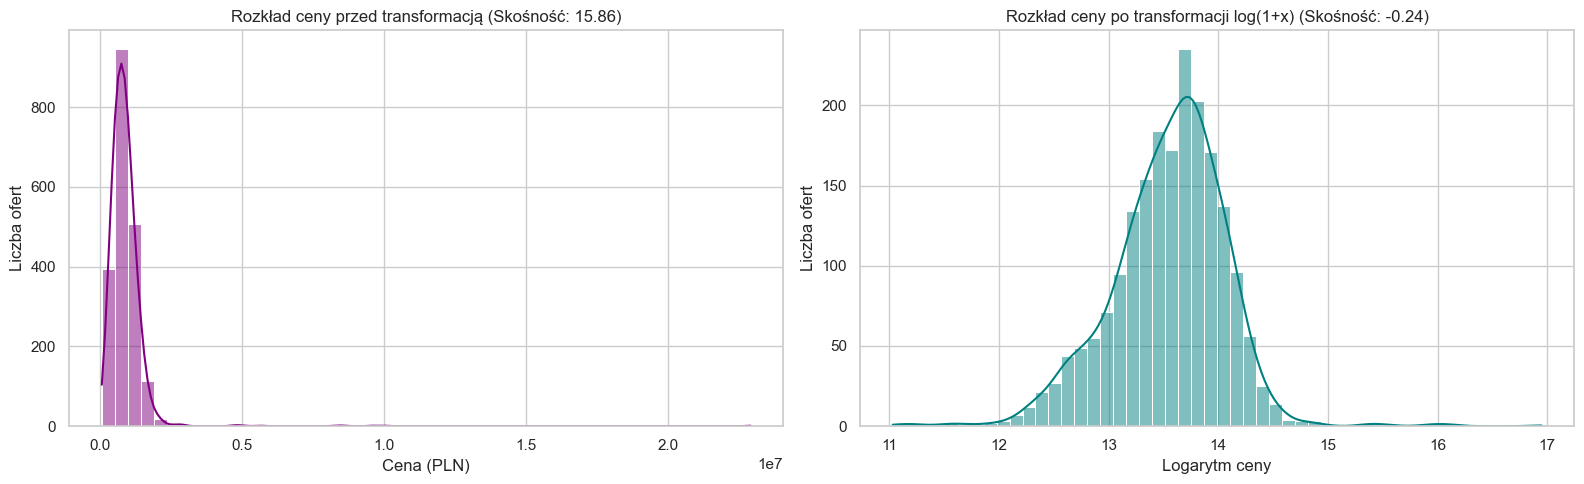


Zapisano oczyszczony zbiór do pliku 'mieszkania_warszawa_clean.csv'


In [7]:
# 1. Usunięcie wierszy z nielogicznym rokiem budowy
df_clean = df[~mask_rok_bzdurny].copy()
print(f"Rozmiar przed czyszczeniem roku budowy: {df.shape}")
print(f"Rozmiar po czyszczeniu roku budowy:    {df_clean.shape}")

# 2. Winsoryzacja ceny (cap na 1 i 99 percentylu)
lower_limit = df_clean["cena_pln"].quantile(0.01)
upper_limit = df_clean["cena_pln"].quantile(0.99)
df_clean["cena_pln_capped"] = df_clean["cena_pln"].clip(lower=lower_limit, upper=upper_limit)

print(f"\nWinsoryzacja - dolny cap (1%): {lower_limit:.2f} PLN")
print(f"Winsoryzacja - górny cap (99%): {upper_limit:.2f} PLN")

# 3. Transformacja logarytmiczna log1p(cena_pln)
df_clean["cena_pln_log"] = np.log1p(df_clean["cena_pln"])

# Porównanie skośności
skew_before = df_clean["cena_pln"].skew()
skew_after = df_clean["cena_pln_log"].skew()
print(f"\nSkośność ceny przed logarytmowaniem: {skew_before:.4f}")
print(f"Skośność ceny po logarytmowaniu:    {skew_after:.4f}")

# 4. Rysowanie dwóch histogramów obok siebie
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Przed transformacją
sns.histplot(df_clean["cena_pln"], bins=50, kde=True, ax=axes[0], color="purple")
axes[0].set_title(f"Rozkład ceny przed transformacją (Skośność: {skew_before:.2f})", fontsize=12)
axes[0].set_xlabel("Cena (PLN)")
axes[0].set_ylabel("Liczba ofert")

# Po transformacji
sns.histplot(df_clean["cena_pln_log"], bins=50, kde=True, ax=axes[1], color="teal")
axes[1].set_title(f"Rozkład ceny po transformacji log(1+x) (Skośność: {skew_after:.2f})", fontsize=12)
axes[1].set_xlabel("Logarytm ceny")
axes[1].set_ylabel("Liczba ofert")

plt.tight_layout()
plt.show()

# Zapis oczyszczonego pliku do nowego CSV
df_clean.to_csv("mieszkania_warszawa_clean.csv", index=False)
print("\nZapisano oczyszczony zbiór do pliku 'mieszkania_warszawa_clean.csv'")

### Efekty transformacji logarytmicznej:
- **Skośność spadła z 15.86 do -0.24!** To świetny wynik, bo wartości między -0.5 a 0.5 oznaczają rozkład niemal idealnie symetryczny.
- **Wizualnie:** Długi prawy ogon zniknął, a dane skupiły się w ładny kształt dzwonu (zbliżony do rozkładu normalnego). Dzięki temu są gotowe do dalszych analiz i modelowania.

## Podsumowanie (Część 7 — 1 pkt)
Najważniejsze wnioski z analizy:

1. **Ceny są mocno asymetryczne:** Większość mieszkań kosztuje wokół 810 tys. PLN (mediana), ale kilka ofert z kosmosu (nawet 22.9 mln PLN) mocno zniekształca i zawyżea średnią.
2. **Gdzie jest najdrożej?** Bez zaskoczeń – **Śródmieście** to najdroższa dzielnica (mediana **~20.4k PLN/m²**), a najtaniej kupimy na **Białołęce** (mediana **~12.6k PLN/m²**).
3. **Modified Z-score to strzał w dziesiątkę:** Klasyczny Z-score poległ przy wykrywaniu outlierów przez efekt maskowania (outliery zniekształciły średnią). Metoda oparta na medianie i MAD okazała się o wiele skuteczniejsza i stabilniejsza.
4. **Logarytmowanie zdziałało cuda:** Użycie `np.log1p` sprowadziło skośność z poziomu 15.86 do zaledwie -0.24, dając nam piękny, symetryczny rozkład.
5. **Co wpływa na cenę?** Najważniejsze są liczba pokoi i metraż. Odległość od centrum ma mniejszy, ujemny wpływ.